비모수 검정
- t검정, ANOVA에 맞지 않을 때
- 데이터가 편향되어 있을 때
- 순위를 이용하는 비모수 검정 3가지

In [10]:
import pandas as pd
df = pd.read_csv("../data/07-8_seoul_market_sales.csv")
df.head(3)

,기준_년분기_코드,상권_구분_코드_명,상권_코드_명,서비스_업종_코드_명,당월_매출_금액,당월_매출_건수,주중_매출_금액,주말_매출_금액,남성_매출_금액,여성_매출_금액,연령대_10_매출_금액,연령대_20_매출_금액,연령대_30_매출_금액,연령대_40_매출_금액,연령대_50_매출_금액,연령대_60_이상_매출_금액
0,20254,발달상권,"신촌역(신촌역, 신촌로터리)",스포츠 강습,190574012,563,185879107,4694905,62004846,122818273,1578072,62149177,70583498,12783010,35309971,2419391
1,20254,전통시장,동화동 골목형상점가,미용실,241121913,7596,158201210,82920703,110263603,126565631,689103,17374758,40986830,66989251,63290864,47498428
2,20254,전통시장,노량진중앙시장,커피-음료,143339677,43869,95844027,47495650,84490667,57487331,2121862,42653948,43692418,15772423,24945022,12792323


In [29]:
# 상권 매출 시각화 비교
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy import stats

plt.rcParams["font.family"] = "Malgun Gothic"   # 한글 깨짐 방지(윈도우 기본 폰트)
plt.rcParams["axes.unicode_minus"] = False

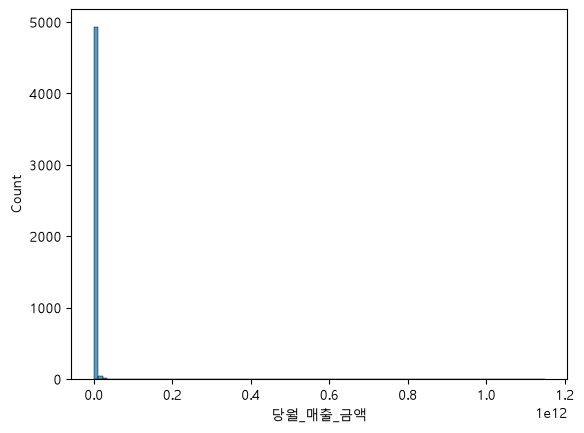

In [12]:
# 시각화 하여 데이터 분포도 보기
sns.histplot(df['당월_매출_금액'],bins=100)
plt.show()

In [15]:
# df['당월_매출_금액'] > 148993825259.sum()
df.columns

Index(['기준_년분기_코드', '상권_구분_코드_명', '상권_코드_명', '서비스_업종_코드_명', '당월_매출_금액',
       '당월_매출_건수', '주중_매출_금액', '주말_매출_금액', '남성_매출_금액', '여성_매출_금액',
       '연령대_10_매출_금액', '연령대_20_매출_금액', '연령대_30_매출_금액', '연령대_40_매출_금액',
       '연령대_50_매출_금액', '연령대_60_이상_매출_금액'],
      dtype='str')

### 1. Mann-whitney U
- 관광 특구와 골목상권 매출이 다를까?
- 서로다른 두그룹의 검정 -> 데이터가 몰려 있으니 -> 비모수 검정

In [20]:
tourism = df[df['상권_구분_코드_명']=='관광특구']['당월_매출_금액']
tourism

5       1090502870
10     19821674944
22       114000000
29     18616130631
30       704296961
36     12038487576
51        90000000
65     19619504901
70     11057699566
75       790835452
85       993894740
88      1263718012
96       339619928
101     1866670692
102      283917628
109     2122165563
118       22473161
122      481298824
123       32254075
126    37590684161
142      100849524
147       99530236
153    11841808566
154      997662865
162    30274206862
163      486052681
167     7576428476
168    12647910506
172      375948041
178     3785616058
179     8506918101
180      168614145
181     1505453498
182     3962190284
188    17790000000
192     9774262366
193       48084971
194        4983827
195     2762748943
199       25317373
203      357310270
206         450468
231      755551967
232     1081234992
234     1267844733
237     3664278251
239      805028992
246        6463762
Name: 당월_매출_금액, dtype: int64

In [21]:
street = df[df['상권_구분_코드_명']=='골목상권']['당월_매출_금액']
street 


3          7965729
8        814448689
16      3124902801
18        78113534
19        30000000
           ...    
4986      48135275
4990     263953106
4995     513452201
4998     476630508
4999      19289211
Name: 당월_매출_금액, Length: 2492, dtype: int64

In [22]:
print("관광특구",tourism.median())
print("골목상권",street.median())

관광특구 1039448928.5
골목상권 101829029.5


In [30]:
u, p = stats.mannwhitneyu(tourism,street)
print('p-value' , f"{p:.6f}")
print("u",u)

p-value 0.000000
u 92865.0


In [ ]:
2. wilcoxon
- 대응하는 두조건을 검증 대응 t검정 대안
- 같은 상권의 주중 매출, 주말 매출 다른지
- 같은 상권 -> 대응 t검정을 해야 하는데 데이터가 몰려 있으니 -> 비모수 검정

In [ ]:
w, p = stats.wilcoxon(df['주중_매출_금액'],df['주말_매출_금액']) # 종 모양 t 검정
print('p-value' , f"{p:.6f}")

p-value 0.000000


### 3. kruskal-wallis - 세그룹 이상 - anova 대안


In [ ]:
groups = [] # 평균은 쏠려있을 때 의미가 없어 중앙값을 사용한다

for name, g in df.groupby('상권_구분_코드_명'):
    # print(name,g)
    groups.append(g['당월_매출_금액'].values)
h, p = stats.kruskal(*groups)
print('통계량 ', h)
print('p-value' , f"{p:.6f}")

통계량  454.1409256281272
p-value 0.000000


In [ ]:
변수, 